In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from datetime import datetime
from tqdm import tqdm
from torch.optim import LBFGS
import torch.nn as nn


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

class ChebyKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree):
        super(ChebyKANLayer, self).__init__()
        self.inputdim = input_dim
        self.outdim = output_dim
        self.degree = degree

        self.cheby_coeffs = nn.Parameter(torch.empty(input_dim, output_dim, degree + 1))
        nn.init.normal_(self.cheby_coeffs, mean=0.0, std=1/(input_dim * (degree + 1)))

    def forward(self, x):
        x = torch.reshape(x, (-1, self.inputdim))  # shape = (batch_size, inputdim)
        # Since Chebyshev polynomial is defined in [-1, 1]
        # We need to normalize x to [-1, 1] using tanh
        x = torch.tanh(x)
        # Initialize Chebyshev polynomial tensors
        cheby = torch.ones(x.shape[0], self.inputdim, self.degree + 1, device=x.device)
        if self.degree > 0:
            cheby[:, :, 1] = x
        for i in range(2, self.degree + 1):
            cheby[:, :, i] = 2 * x * cheby[:, :, i - 1].clone() - cheby[:, :, i - 2].clone()
        # Compute the Chebyshev interpolation
        y = torch.einsum('bid,iod->bo', cheby, self.cheby_coeffs)  # shape = (batch_size, outdim)
        y = y.view(-1, self.outdim)
        return y
        

/home/defuser/miniconda3/envs/KAN/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [2]:
best_params_CA = {
    "depth": 3,
    "neurons_layer_0": 65,
    "neurons_layer_1": 130,
    "neurons_layer_2": 130,
    "orders_layer_0": 2,
    "orders_layer_1": 6,
    "orders_layer_2": 2,        
}

# best_params: {'depth': 2, 'neurons_layer_0': 155, 'neurons_layer_1': 95, 'orders_layer_0': 4, 'orders_layer_1': 6}

In [3]:
EPOCHS = 100
TRIALS = 10

DATA = 'CA'
# data = pd.read_csv("../DATA/%s.csv" % DATA)
data = pd.read_csv("/home/data3/Ali/Code/KAN/Afzal/DATA/%s.csv" % DATA)

data.fillna(0, inplace=True)
y = data["target_label"].values
data.drop("target_label", axis=1, inplace=True)
X = data.values.astype(np.float32)

if y.dtype == "object":
    label_encoder = LabelEncoder()
    y = torch.tensor(label_encoder.fit_transform(y))
else:
    y = torch.tensor(y)


X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, stratify=y_train, test_size=0.1, random_state=42)

scaler = StandardScaler()
X_train = torch.tensor(scaler.fit_transform(X_train)).to(device)
X_valid = torch.tensor(scaler.transform(X_valid)).to(device)
X_test = torch.tensor(scaler.transform(X_test)).to(device)

y_train = torch.nn.functional.one_hot(y_train.long(), num_classes=2).to(device).float()
y_valid = torch.nn.functional.one_hot(y_valid.long(), num_classes=2).to(device).float()
y_test = torch.nn.functional.one_hot(y_test.long(), num_classes=2).to(device).float()

input_shape = X_train.shape[1]
output_shape = y_train.shape[1]

# print("Reduce number of features from %d to %d." % (data.shape[1], input_shape))

dataset = {
    "train_input": X_train,
    "train_label": y_train,
    "test_input": X_valid,
    "test_label": y_valid,
}


def fit(model, dataset, steps=100, loss_fn=None, lr=1., batch=-1):
    pbar = tqdm(range(steps), desc='description', ncols=100)
    optimizer = LBFGS(model.parameters(), lr=lr, history_size=10, line_search_fn="strong_wolfe", tolerance_grad=1e-32, tolerance_change=1e-32)

    results = {}
    results['train_loss'] = []
    results['test_loss'] = []

    if batch == -1 or batch > dataset['train_input'].shape[0]:
        batch_size = dataset['train_input'].shape[0]
        batch_size_test = dataset['test_input'].shape[0]
    else:
        batch_size = batch
        batch_size_test = batch

    global train_loss

    def closure():
        global train_loss
        optimizer.zero_grad()
        pred = model.forward(dataset['train_input'][train_id])
        train_loss = loss_fn(pred, dataset['train_label'][train_id])
        objective = train_loss
        objective.backward()
        return objective

    for _ in pbar:


        train_id = np.random.choice(dataset['train_input'].shape[0], batch_size, replace=False)
        test_id = np.random.choice(dataset['test_input'].shape[0], batch_size_test, replace=False)

        optimizer.step(closure)

        test_loss = loss_fn(model.forward(dataset['test_input'][test_id]), dataset['test_label'][test_id])

        results['train_loss'].append(torch.sqrt(train_loss).cpu().detach().numpy())
        results['test_loss'].append(torch.sqrt(test_loss).cpu().detach().numpy())
        pbar.set_description("| train_loss: %.2e | test_loss: %.2e " % (torch.sqrt(train_loss).cpu().detach().numpy(), torch.sqrt(test_loss).cpu().detach().numpy()))

    return results

class fKAN(nn.Module):
    def __init__(self, layers, orders):
        super(fKAN, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers) - 2):
            self.layers.append(ChebyKANLayer(layers[i], layers[i + 1], orders[i]))
        self.layers.append(nn.Linear(layers[len(layers) - 2], layers[len(layers) - 1]))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [4]:
# best_params = study.best_params
best_params = best_params_CA
print('best_params:', best_params)

depth = best_params["depth"]
width = [best_params[f"neurons_layer_{i}"] for i in range(depth)]
width = [input_shape] + width + [output_shape]
orders = [best_params[f"orders_layer_{i}"] for i in range(depth)]

model = fKAN(width, orders).to(device)
history = fit(model, dataset, steps=EPOCHS, loss_fn=torch.nn.CrossEntropyLoss())

y_score = model(X_test).cpu()
y_pred = (y_score > 0.5).int()


print(classification_report(y_test.cpu(), y_pred, target_names=label_encoder.classes_))
print("ROC-AUC: %.4f" % roc_auc_score(y_test.cpu(), y_pred))

best_params: {'depth': 3, 'neurons_layer_0': 65, 'neurons_layer_1': 130, 'neurons_layer_2': 130, 'orders_layer_0': 2, 'orders_layer_1': 6, 'orders_layer_2': 2}


| train_loss: -0.00e+00 | test_loss: 1.96e+00 : 100%|█████████████| 100/100 [00:05<00:00, 18.22it/s]

              precision    recall  f1-score   support

           +       0.90      0.79      0.84        77
           -       0.82      0.91      0.86        77

   micro avg       0.86      0.85      0.85       154
   macro avg       0.86      0.85      0.85       154
weighted avg       0.86      0.85      0.85       154
 samples avg       0.85      0.85      0.85       154

ROC-AUC: 0.8539



/home/defuser/miniconda3/envs/KAN/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Interpretebility

In [38]:
model

fKAN(
  (layers): ModuleList(
    (0-2): 3 x ChebyKANLayer()
    (3): Linear(in_features=130, out_features=2, bias=True)
  )
)

In [33]:
# Get the first ChebyKANLayer
first_layer = model.layers[1]

# Get the Chebyshev coefficients for all features and outputs
# Shape: (input_dim, output_dim, degree + 1)
cheby_coeffs = first_layer.cheby_coeffs.data.cpu().numpy()

# For feature i (e.g., i=0), output j (e.g., j=0), and polynomial degree k (e.g., k=0,1,2)
feature_idx = 0
output_idx = 2
coefficients = cheby_coeffs[feature_idx, output_idx, :]

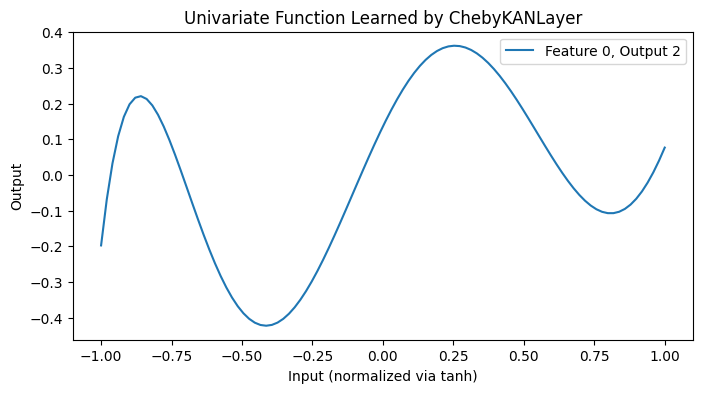

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def chebyshev_polynomial(x, degree):
    if degree == 0:
        return np.ones_like(x)
    elif degree == 1:
        return x
    else:
        return 2 * x * chebyshev_polynomial(x, degree-1) - chebyshev_polynomial(x, degree-2)

# Feature index and output index to analyze
# feature_idx = 0
# output_idx = 0

# Extract coefficients for feature i and output j
coefficients = cheby_coeffs[feature_idx, output_idx, :]
degree = first_layer.degree

# Generate input values (normalized to [-1, 1] via tanh, as in the forward pass)
x = np.linspace(-1, 1, 100)
y = np.zeros_like(x)

for k in range(degree + 1):
    y += coefficients[k] * chebyshev_polynomial(x, k)

# Plot the univariate function
plt.figure(figsize=(8, 4))
plt.plot(x, y, label=f'Feature {feature_idx}, Output {output_idx}')
plt.xlabel('Input (normalized via tanh)')
plt.ylabel('Output')
plt.title('Univariate Function Learned by ChebyKANLayer')
plt.legend()
plt.show()

In [35]:
for feature_idx in range(cheby_coeffs.shape[0]):
    for output_idx in range(cheby_coeffs.shape[1]):
        coefficients = cheby_coeffs[feature_idx, output_idx, :]
        # Reconstruct and plot the univariate function...

In [36]:
# Raw feature value (e.g., 1.5)
raw_value = 1.5

# Normalize via tanh (as in the forward pass)
normalized_value = np.tanh(raw_value)

# Compute the Chebyshev polynomial output
y = 0
for k in range(degree + 1):
    y += coefficients[k] * chebyshev_polynomial(normalized_value, k)

print(f"Raw value: {raw_value}, Normalized: {normalized_value:.4f}, Output: {y:.4f}")

Raw value: 1.5, Normalized: 0.9051, Output: -0.0292
